In [2]:
import pandas as pd
import matplotlib.pyplot as plt

smoke = pd.read_csv("visits_with_smoke_detailed_pings.csv")

In [3]:
smoke = smoke[smoke['date'] <= '2023-12-11']

In [4]:
smoke

,date,layer,polygon_id,unique_visits,total_pings,avg_pings_per_device,avg_time_range_minutes,avg_time_between_pings_minutes,city,city_code,city_normalized,weighted_avg_smoke_pm,n_grids,smoke_category
0,2022-01-01,outdoor_sports_facilities,42,18,28,1.588235,149.596078,-207.109722,Florence,Lincoln City,Florence,0.0,0.0,No Smoke
1,2022-01-02,outdoor_sports_facilities,42,22,85,3.785714,351.682143,2.347293,Florence,Lincoln City,Florence,0.0,0.0,No Smoke
2,2022-01-03,outdoor_sports_facilities,42,28,128,4.782609,313.587319,10.710386,Florence,Lincoln City,Florence,0.0,0.0,No Smoke
3,2022-01-04,outdoor_sports_facilities,42,30,126,4.543478,731.101449,-78.353223,Florence,Lincoln City,Florence,0.0,0.0,No Smoke
4,2022-01-05,outdoor_sports_facilities,42,21,41,1.975000,183.915833,148.966880,Florence,Lincoln City,Florence,0.0,0.0,No Smoke
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6673635,2023-12-11,parks,8143,3,3,1.000000,0.000000,NaN,White City,Medford,White City,0.0,0.0,No Smoke
6673636,2023-12-11,parks,8144,1,1,1.000000,0.000000,NaN,White City,Medford,White City,0.0,0.0,No Smoke
6673637,2023-12-11,parks,8139,2,2,1.000000,0.000000,NaN,White City,Medford,White City,0.0,0.0,No Smoke
6673638,2023-12-11,parks,8138,313,365,1.096202,0.789739,-1.186584,White City,Medford,White City,0.0,0.0,No Smoke


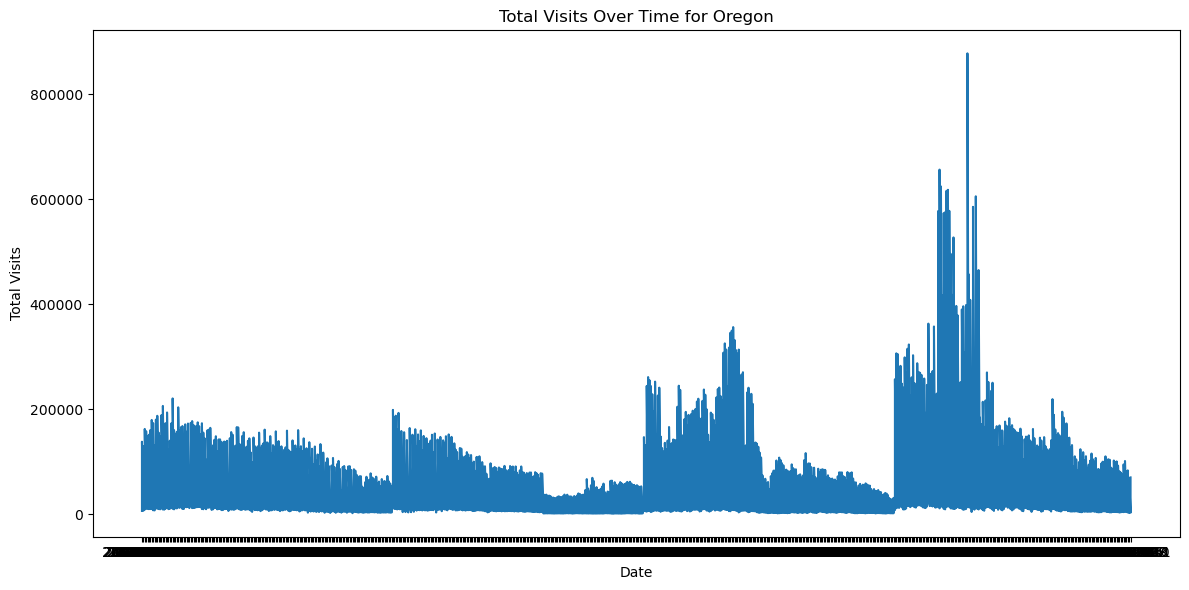

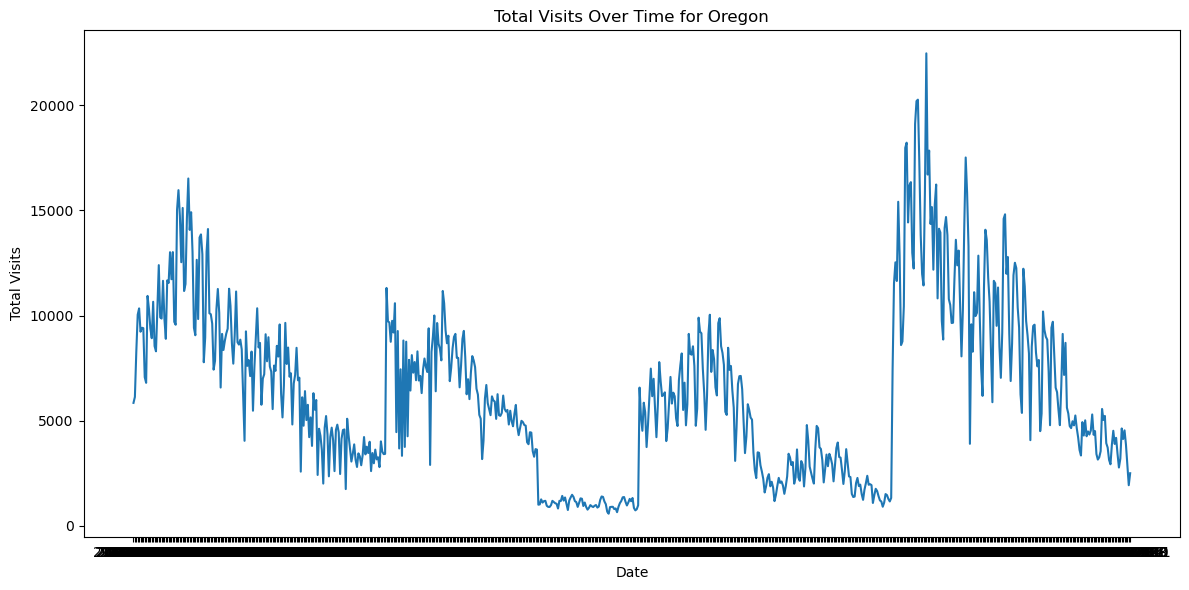

In [6]:
daily_visits = (
    smoke
    .groupby(['date','layer'])['unique_visits']
    .sum()
    .reset_index()
)
plt.figure(figsize = (12,6))
plt.plot(
    daily_visits['date'],
    daily_visits['unique_visits'],
)

plt.title("Total Visits Over Time for Oregon")
plt.xlabel("Date")
plt.ylabel("Total Visits")
plt.tight_layout()
plt.show()
plt.figure(figsize = (12,6))
plt.plot(
    daily_visits[daily_visits['layer'] == "indoor_sports_facilities"]['date'],
    daily_visits[daily_visits['layer'] == "indoor_sports_facilities"]['unique_visits'],
)

plt.title("Total Visits Over Time for Oregon")
plt.xlabel("Date")
plt.ylabel("Total Visits")
plt.tight_layout()
plt.show()

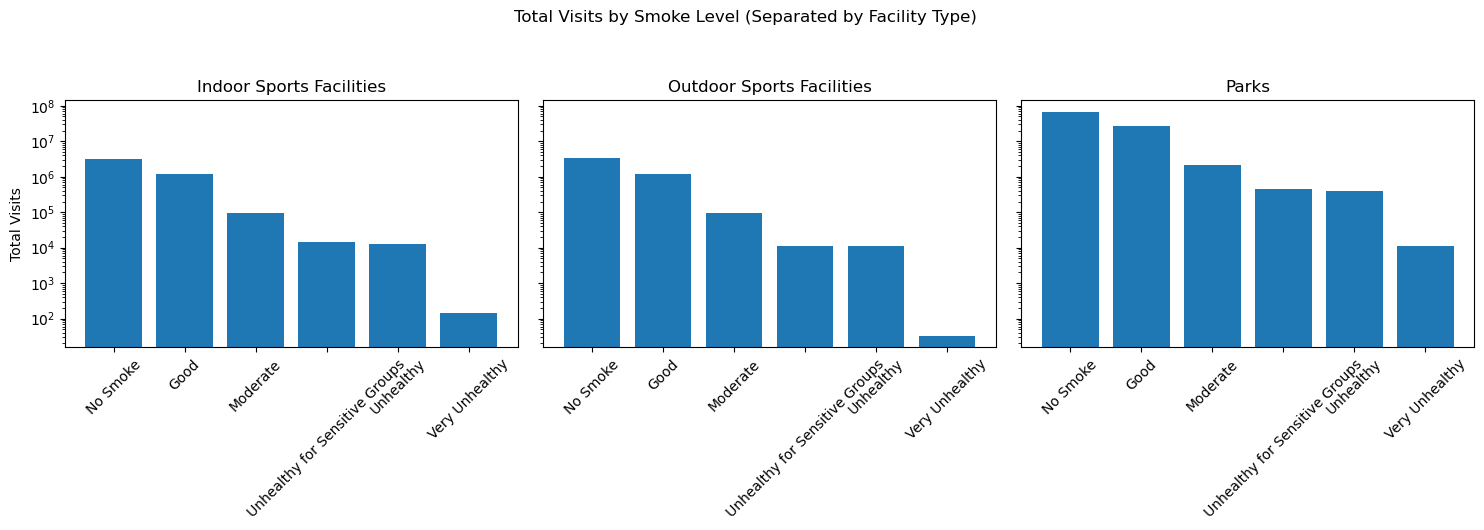

In [7]:
daily_visit_levels = (
    smoke
    .groupby(['smoke_category', 'layer'])['unique_visits']
    .sum()
    .reset_index()
)

# Optional ordering
smoke_order = [
    'No Smoke',
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy'
]

layers = daily_visit_levels['layer'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(layers),
    figsize=(5 * len(layers), 5),
    sharey=True
)

for ax, layer in zip(axes, layers):
    df_layer = (
        daily_visit_levels[daily_visit_levels['layer'] == layer]
        .set_index('smoke_category')
        .loc[smoke_order]
    )

    ax.bar(df_layer.index, df_layer['unique_visits'])
    ax.set_title(layer.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=45)
    ax.set_yscale("log")


axes[0].set_ylabel("Total Visits")
fig.suptitle("Total Visits by Smoke Level (Separated by Facility Type)", y=1.05)

plt.tight_layout()
plt.show()





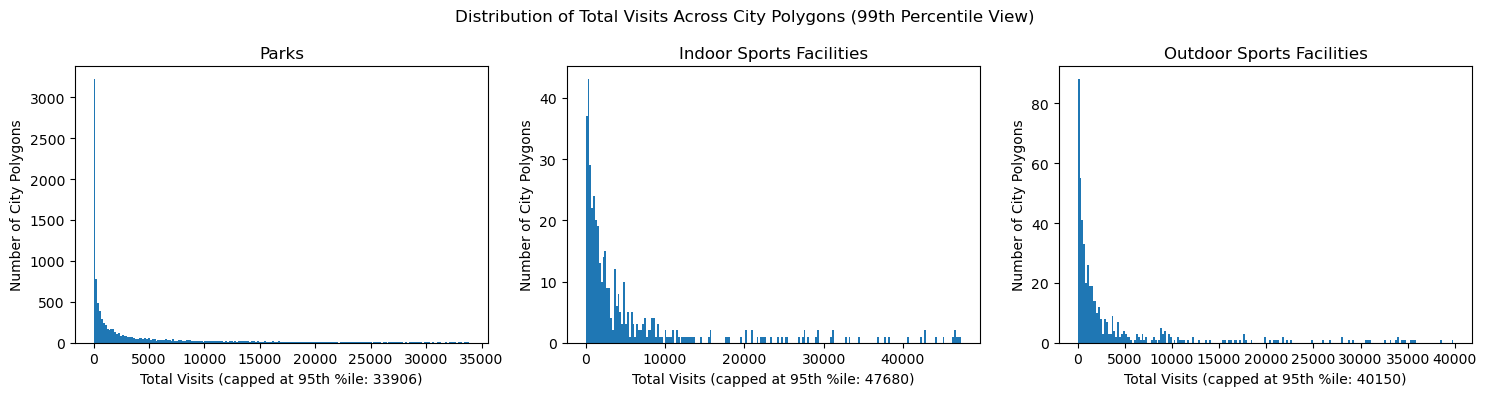

In [8]:
daily_visit_levels = (
    smoke
    .groupby(['city', 'layer', 'polygon_id'])['unique_visits']
    .sum()
    .reset_index()
)
layers = daily_visit_levels['layer'].unique()
fig, axes = plt.subplots(
    1, len(layers),
    figsize=(5 * len(layers), 4),
    sharey=False  # Changed from True
)
for ax, layer in zip(axes, layers):
    df_layer = daily_visit_levels[
        daily_visit_levels['layer'] == layer
    ]
    
    # Cap at 99th percentile
    p95 = df_layer['unique_visits'].quantile(0.95)
    df_capped = df_layer[df_layer['unique_visits'] <= p95]
    
    ax.hist(df_capped['unique_visits'], bins=200)
    ax.set_title(layer.replace('_', ' ').title())
    ax.set_xlabel(f"Total Visits (capped at 95th %ile: {p95:.0f})")
    ax.set_ylabel("Number of City Polygons") 
fig.suptitle("Distribution of Total Visits Across City Polygons (99th Percentile View)")
plt.tight_layout()
plt.show()

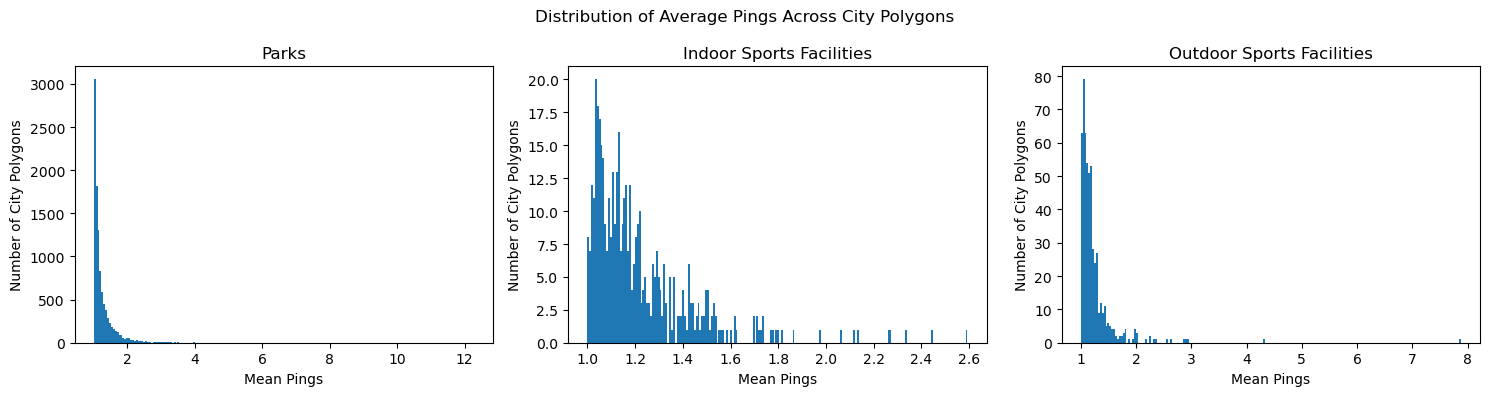

In [9]:
daily_visit_levels = (
    smoke
    .groupby(['city', 'layer', 'polygon_id'])['avg_pings_per_device']
    .mean()
    .reset_index()
)
layers = daily_visit_levels['layer'].unique()
fig, axes = plt.subplots(
    1, len(layers),
    figsize=(5 * len(layers), 4),
    sharey=False  # Changed from True
)
for ax, layer in zip(axes, layers):
    df_layer = daily_visit_levels[
        daily_visit_levels['layer'] == layer
    ]
    
    ax.hist(df_layer['avg_pings_per_device'], bins=200)
    ax.set_title(layer.replace('_', ' ').title())
    ax.set_xlabel(f"Mean Pings")
    ax.set_ylabel("Number of City Polygons") 
fig.suptitle("Distribution of Average Pings Across City Polygons")
plt.tight_layout()
plt.show()

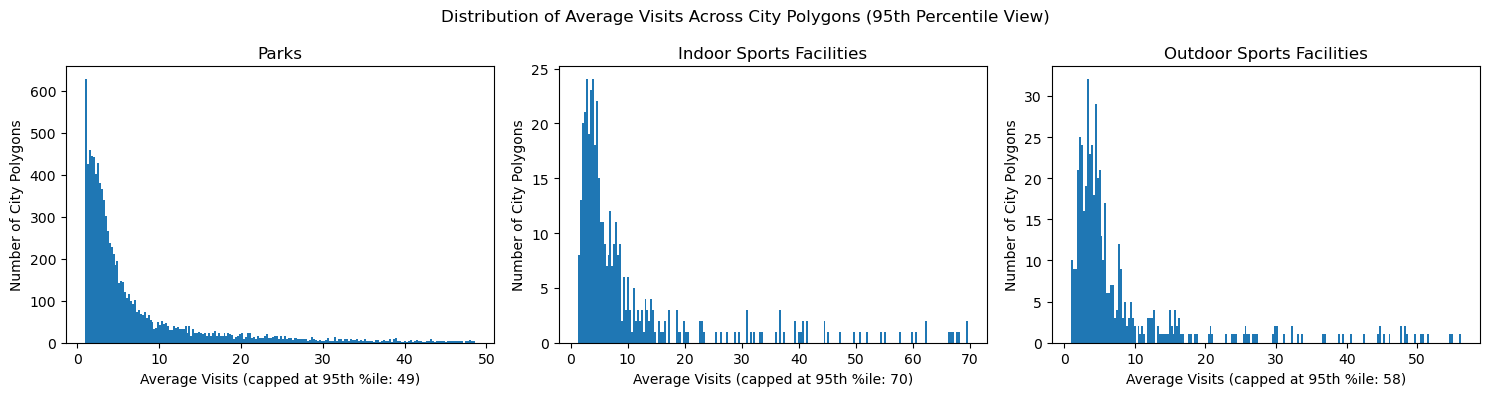

In [12]:
daily_visit_levels = (
    smoke
    .groupby(['city', 'layer', 'polygon_id'])['unique_visits']
    .mean()
    .reset_index()
)
layers = daily_visit_levels['layer'].unique()
fig, axes = plt.subplots(
    1, len(layers),
    figsize=(5 * len(layers), 4),
    sharey=False  # Changed from True
)
for ax, layer in zip(axes, layers):
    df_layer = daily_visit_levels[
        daily_visit_levels['layer'] == layer
    ]
    
    # Cap at 99th percentile
    p95 = df_layer['unique_visits'].quantile(0.95)
    df_capped = df_layer[df_layer['unique_visits'] <= p95]
    
    ax.hist(df_capped['unique_visits'], bins=200)
    ax.set_title(layer.replace('_', ' ').title())
    ax.set_xlabel(f"Average Visits (capped at 95th %ile: {p95:.0f})")
    ax.set_ylabel("Number of City Polygons") 
fig.suptitle("Distribution of Average Visits Across City Polygons (95th Percentile View)")
plt.tight_layout()
plt.show()